In [25]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

from pre_processing import processed_img_preview, img_processing


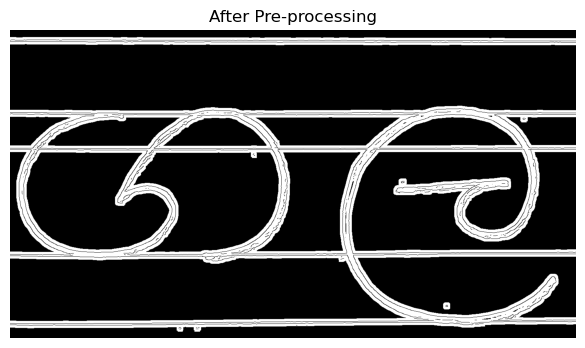

In [26]:
IMAGE_PATH = "./dataset/word2.png"

img = cv2.imread(IMAGE_PATH)

if img is None:
    raise ValueError("Image not found")

clean = img_processing(img)

plt.figure(figsize=(8,4))
plt.imshow(clean, cmap="gray")
plt.title("After Pre-processing")
plt.axis("off")
plt.show()


In [27]:
def vertical_projection(binary_img):
    # sum white pixels column-wise
    return np.sum(binary_img > 0, axis=0)


In [28]:
def smooth_projection(proj):
    # Savitzky–Golay smoothing
    return savgol_filter(proj, 21, 3)


In [29]:
def find_split_points(proj, num_letters, margin_ratio=0.06):
    """
    Valley-first split logic.
    Finds the deepest valleys instead of equal-width zones.
    """

    w = len(proj)
    margin = int(w * margin_ratio)

    # valid search region (ignore start/end noise)
    valid_proj = proj[margin : w - margin]

    # safety check
    if len(valid_proj) == 0 or num_letters <= 1:
        return []

    # find all local minima
    minima = []
    for i in range(1, len(valid_proj) - 1):
        if valid_proj[i] < valid_proj[i - 1] and valid_proj[i] < valid_proj[i + 1]:
            minima.append(i + margin)

    # if no local minima found, fallback to global minimum
    if not minima:
        split = np.argmin(valid_proj) + margin
        return [split] if num_letters == 2 else []

    # sort valleys by depth (lowest first)
    minima = sorted(minima, key=lambda x: proj[x])

    # pick deepest (num_letters - 1) valleys
    splits = sorted(minima[: num_letters - 1])

    return splits


In [30]:
def split_by_vertical_projection(binary_img, num_letters):
    proj = vertical_projection(binary_img)
    proj_smooth = smooth_projection(proj)

    splits = find_split_points(proj_smooth, num_letters)

    h, w = binary_img.shape
    xs = [0] + splits + [w]

    letters = []
    for i in range(len(xs) - 1):
        part = binary_img[:, xs[i]:xs[i+1]]
        letters.append(part)

    return letters, proj_smooth, splits


In [31]:
def preview_projection(binary_img, proj, splits):
    plt.figure(figsize=(10,3))
    plt.plot(proj)
    for s in splits:
        plt.axvline(s, color="red")
    plt.title("Vertical Projection + Split Points")
    plt.show()


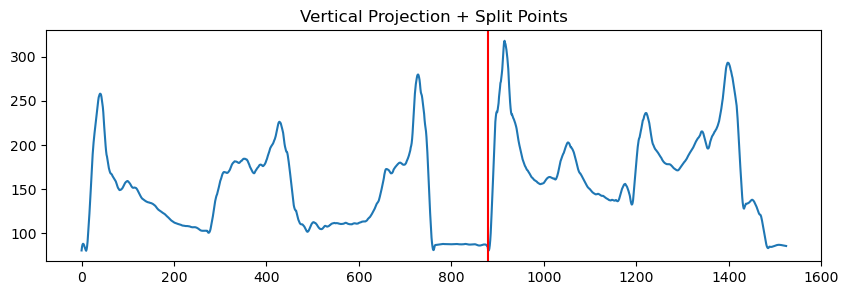

In [32]:
num_letters = 2

letters, proj, splits = split_by_vertical_projection(clean, num_letters)

preview_projection(clean, proj, splits)


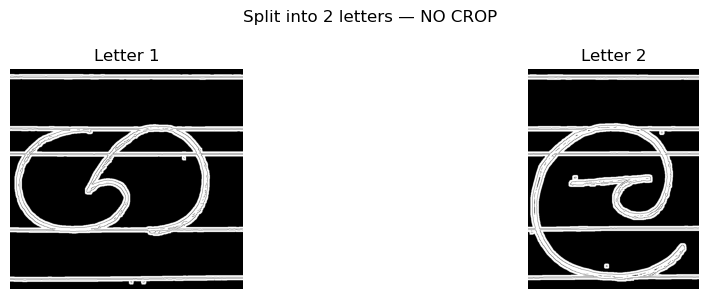

In [33]:
plt.figure(figsize=(12,3))

for i, l in enumerate(letters):
    plt.subplot(1, len(letters), i+1)
    plt.imshow(l, cmap="gray")
    plt.title(f"Letter {i+1}")
    plt.axis("off")

plt.suptitle(f"Split into {len(letters)} letters — NO CROP")
plt.tight_layout()
plt.show()


In [34]:
def tight_crop(img):
    ys, xs = np.where(img > 0)
    if len(xs) == 0:
        return img
    return img[ys.min():ys.max()+1, xs.min():xs.max()+1]


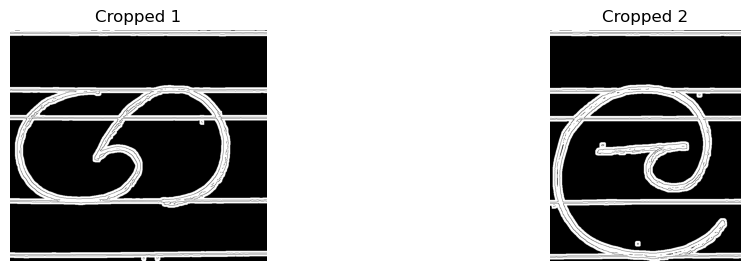

In [35]:
cropped_letters = [tight_crop(l) for l in letters]

plt.figure(figsize=(12,3))
for i, l in enumerate(cropped_letters):
    plt.subplot(1, len(cropped_letters), i+1)
    plt.imshow(l, cmap="gray")
    plt.title(f"Cropped {i+1}")
    plt.axis("off")
plt.show()


In [36]:
out_dir = "segmented_letters"
os.makedirs(out_dir, exist_ok=True)

for i, l in enumerate(cropped_letters):
    cv2.imwrite(f"{out_dir}/char_{i+1}.png", l)

print("Saved segmented letters to:", out_dir)


Saved segmented letters to: segmented_letters
